# 🌐 The Global Semiconductor Industry, 2010–2026

> **An exploratory data analysis of the industry that runs the modern world** — from foundry
> revenue and the AI-chip boom, to memory price cycles, the fab-capacity race, and the
> geopolitics of export controls.

This notebook explores five linked datasets covering the semiconductor value chain:

| Dataset | What it captures |
|---|---|
| **Company financials** | Revenue, margins, R&D and capex for 40 companies, 2010–2026 |
| **AI chip market** | Shipments, ASP, revenue, compute (TFLOPS) and power (TDP) for AI accelerators |
| **Chip prices** | Monthly prices for DRAM, NAND, HBM3 and NVIDIA data-center GPUs |
| **Fab capacity** | Monthly wafer capacity by company, country and process node |
| **Export controls** | Geopolitical actions (2018–2026) with a severity score |

**Story arc:** ① How big is the industry and who leads → ② the AI-chip explosion →
③ memory & accelerator price dynamics → ④ the race for fab capacity → ⑤ the geopolitical
overlay reshaping all of it.

*If you find this useful, an upvote is appreciated 🙂*


In [1]:
# ============================================================
#  Setup: imports, a consistent chart style, and data loading
# ============================================================
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ---- A small, colorblind-safe design system (fixed categorical order) ----
INK       = "#0b0b0b"   # primary text
INK_SOFT  = "#52514e"   # secondary text
MUTED     = "#898781"   # axis / tick labels
GRID      = "#e1e0d9"   # hairline gridlines
SURFACE   = "#fcfcfb"   # chart surface
# Categorical hues, assigned in this fixed order (never cycled by rank):
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
       "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED, MAGENTA, ORANGE = CAT
# Single-hue blue ramp for magnitude (sequential):
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 11,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.edgecolor": "#c3c2b7",
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.linewidth": 0.8,
    "figure.dpi": 110, "axes.titlesize": 14, "axes.titleweight": "bold",
})


def style(ax, title=None, sub=None, ylab=None, xlab=None):
    # Apply the recessive-chrome house style to an Axes.
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, loc="left", color=INK, pad=14 if sub else 8)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, ha="left", va="bottom",
                color=MUTED, fontsize=10.5)
    if ylab: ax.set_ylabel(ylab, color=INK_SOFT)
    if xlab: ax.set_xlabel(xlab, color=INK_SOFT)
    ax.tick_params(length=0)
    return ax


# ---- Locate the data (works on Kaggle and locally) ----
def find_data_dir():
    candidates = glob.glob("/kaggle/input/*/") + [
        "/kaggle/input/global-semiconductor-industry-2010-2026",
        ".", os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else ".",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "chip_companies_financials.csv")):
            return c
    return "."

DATA = find_data_dir()
print("Reading data from:", DATA)

fin    = pd.read_csv(os.path.join(DATA, "chip_companies_financials.csv"))
ai     = pd.read_csv(os.path.join(DATA, "ai_chip_market.csv"))
prices = pd.read_csv(os.path.join(DATA, "chip_prices.csv"))
fab    = pd.read_csv(os.path.join(DATA, "fab_capacity.csv"))
ctrl   = pd.read_csv(os.path.join(DATA, "export_controls.csv"))

for name, df in [("financials", fin), ("ai_chip", ai), ("prices", prices),
                 ("fab_capacity", fab), ("export_controls", ctrl)]:
    print(f"  {name:16s} {df.shape[0]:>4} rows x {df.shape[1]} cols")

Reading data from: .
  financials        617 rows x 10 cols
  ai_chip           120 rows x 11 cols
  prices            405 rows x 6 cols
  fab_capacity      313 rows x 7 cols
  export_controls    34 rows x 15 cols


## 1 · How big is the industry — and who leads?

We start at the top: total tracked revenue across the value chain, how it splits by business
model, and which companies sit at the top of the stack.

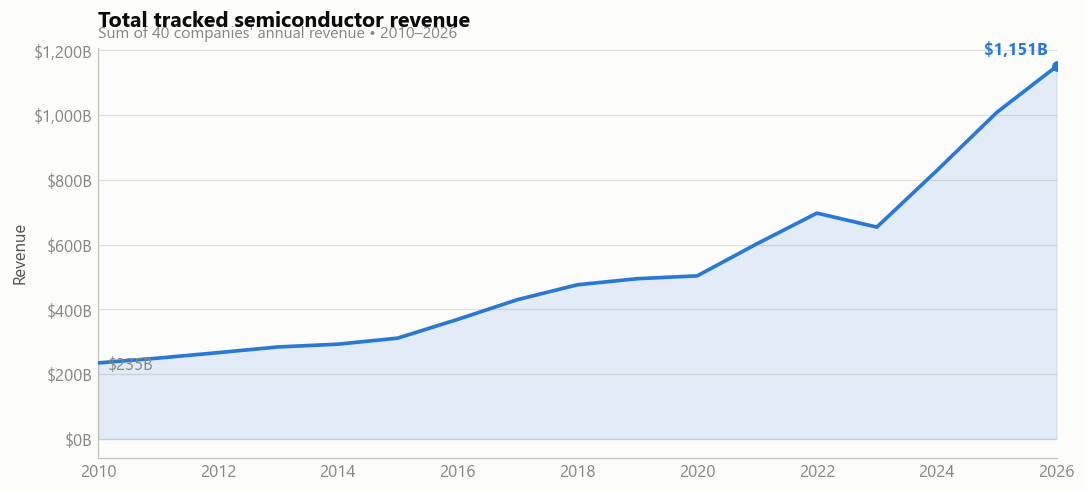

~10.4% compound annual growth from $235B (2010) to $1,151B (2026).


In [2]:
# Total tracked revenue by year, and how it splits across business models
seg_family = {
    "foundry": "Foundry",
    "eda_software": "EDA tools",
}
def family(seg):
    if seg in seg_family: return seg_family[seg]
    if seg.startswith("fabless"):   return "Fabless"
    if seg.startswith("idm"):       return "IDM"
    if seg.startswith("equipment"): return "Equipment"
    return "Other"

fin["family"] = fin["segment"].map(family)

by_year = fin.groupby("year")["revenue_usd_bn"].sum()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.fill_between(by_year.index, by_year.values, color=BLUE, alpha=0.12, zorder=1)
ax.plot(by_year.index, by_year.values, color=BLUE, lw=2.4, zorder=3)
ax.scatter([by_year.index[-1]], [by_year.values[-1]], color=BLUE, s=36, zorder=4)
ax.annotate(f"${by_year.values[-1]:,.0f}B",
            (by_year.index[-1], by_year.values[-1]),
            textcoords="offset points", xytext=(-6, 8), ha="right",
            color=BLUE, fontweight="bold")
ax.annotate(f"${by_year.values[0]:,.0f}B",
            (by_year.index[0], by_year.values[0]),
            textcoords="offset points", xytext=(6, -4), ha="left", color=MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_xlim(by_year.index.min(), by_year.index.max())
style(ax, "Total tracked semiconductor revenue",
      "Sum of 40 companies' annual revenue • 2010–2026", ylab="Revenue")
plt.tight_layout(); plt.show()

cagr = (by_year.values[-1] / by_year.values[0]) ** (1/(len(by_year)-1)) - 1
print(f"~{cagr*100:.1f}% compound annual growth from ${by_year.values[0]:,.0f}B "
      f"(2010) to ${by_year.values[-1]:,.0f}B (2026).")

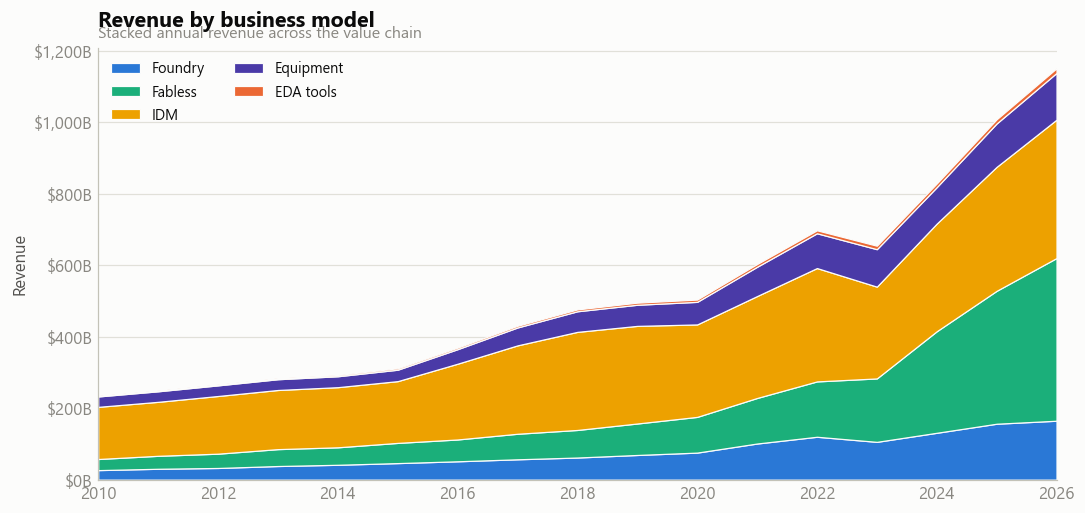

In [3]:
# Revenue split by business model over time (stacked area)
fam_year = (fin.groupby(["year", "family"])["revenue_usd_bn"].sum()
              .unstack("family").fillna(0))
order = ["Foundry", "Fabless", "IDM", "Equipment", "EDA tools"]
order = [c for c in order if c in fam_year.columns]
colors = {"Foundry": BLUE, "Fabless": AQUA, "IDM": YELLOW,
          "Equipment": VIOLET, "EDA tools": ORANGE}

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.stackplot(fam_year.index, [fam_year[c].values for c in order],
             labels=order, colors=[colors[c] for c in order],
             edgecolor=SURFACE, linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_xlim(fam_year.index.min(), fam_year.index.max())
style(ax, "Revenue by business model",
      "Stacked annual revenue across the value chain", ylab="Revenue")
ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2)
plt.tight_layout(); plt.show()

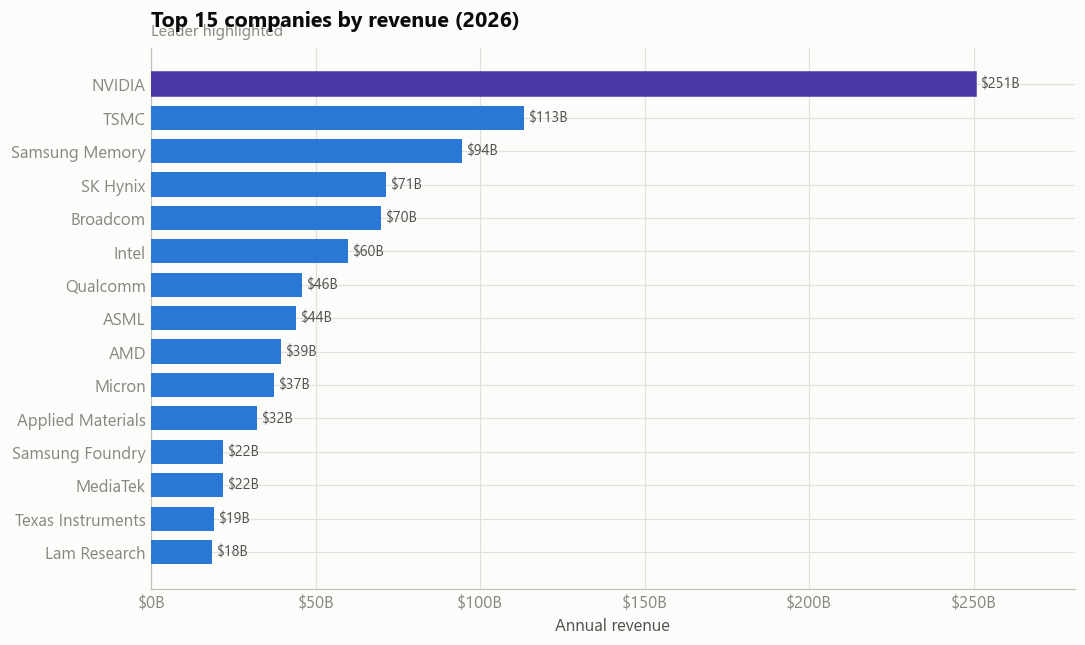

In [4]:
# Top 15 companies by 2026 revenue (ranking -> single hue)
latest = fin[fin.year == fin.year.max()].nlargest(15, "revenue_usd_bn")[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(latest["company_name"], latest["revenue_usd_bn"],
               color=BLUE, height=0.72, zorder=3)
bars[-1].set_color(VIOLET)  # highlight the leader
for b, v in zip(bars, latest["revenue_usd_bn"]):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height()/2,
            f"${v:,.0f}B", va="center", color=INK_SOFT, fontsize=9.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
style(ax, f"Top 15 companies by revenue ({fin.year.max()})",
      "Leader highlighted", xlab="Annual revenue")
plt.tight_layout(); plt.show()

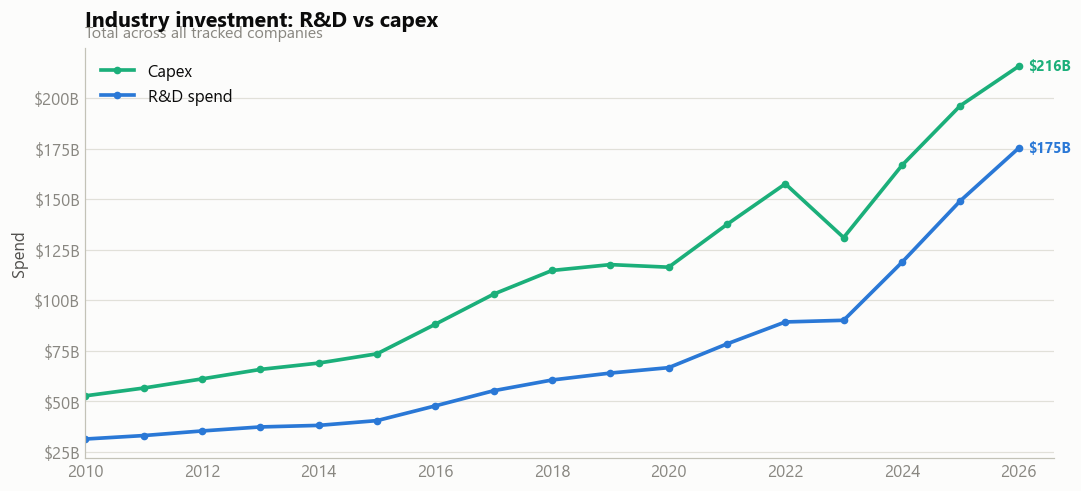

In [5]:
# Industry R&D and capex investment over time (two comparable series, one axis)
inv = fin.groupby("year")[["rd_spend_usd_bn", "capex_usd_bn"]].sum()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(inv.index, inv["capex_usd_bn"], color=AQUA, lw=2.4, marker="o", ms=4, label="Capex")
ax.plot(inv.index, inv["rd_spend_usd_bn"], color=BLUE, lw=2.4, marker="o", ms=4, label="R&D spend")
for col, color in [("capex_usd_bn", AQUA), ("rd_spend_usd_bn", BLUE)]:
    ax.annotate(f"${inv[col].values[-1]:,.0f}B", (inv.index[-1], inv[col].values[-1]),
                textcoords="offset points", xytext=(6, 0), va="center",
                color=color, fontweight="bold", fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_xlim(inv.index.min(), inv.index.max() + 0.6)
style(ax, "Industry investment: R&D vs capex",
      "Total across all tracked companies", ylab="Spend")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

## 2 · The AI-chip boom (2020–2026)

No trend has reshaped the industry like AI accelerators. Here we track estimated revenue by
vendor, the concentration of the market, and the raw growth in compute per chip.

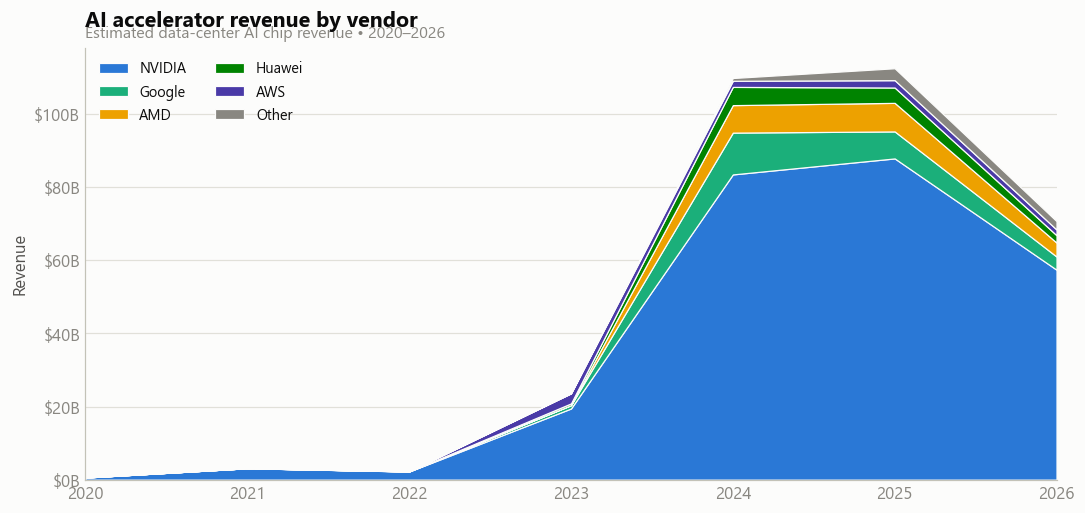

Estimated AI accelerator revenue grew from $0.6B to $70.7B between 2020 and 2026.


In [6]:
# AI accelerator revenue by vendor over time (top vendors + Other)
rev = ai.groupby(["year", "vendor"])["estimated_revenue_usd_m"].sum().unstack("vendor").fillna(0)
totals = rev.sum().sort_values(ascending=False)
top = list(totals.head(5).index)
rev_plot = rev[top].copy()
rev_plot["Other"] = rev.drop(columns=top).sum(axis=1)
series = top + ["Other"]
pal = {name: CAT[i] for i, name in enumerate(top)}
pal["Other"] = MUTED

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.stackplot(rev_plot.index, [rev_plot[s].values/1000 for s in series],
             labels=series, colors=[pal[s] for s in series],
             edgecolor=SURFACE, linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_xlim(rev_plot.index.min(), rev_plot.index.max())
style(ax, "AI accelerator revenue by vendor",
      "Estimated data-center AI chip revenue • 2020–2026", ylab="Revenue")
ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2)
plt.tight_layout(); plt.show()

tot = rev_plot.drop(columns="Other").sum(axis=1) + rev_plot["Other"]
print(f"Estimated AI accelerator revenue grew from ${tot.iloc[0]/1000:,.1f}B "
      f"to ${tot.iloc[-1]/1000:,.1f}B between {rev_plot.index.min()} and {rev_plot.index.max()}.")

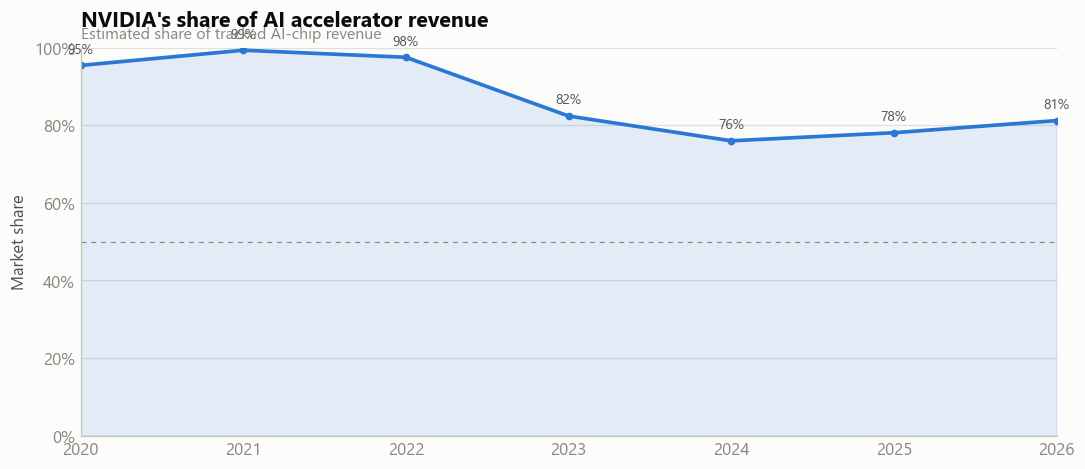

In [7]:
# Market concentration: leading vendor's share of AI-chip revenue
share = (rev.div(rev.sum(axis=1), axis=0) * 100)
leader = totals.index[0]

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.fill_between(share.index, share[leader].values, color=BLUE, alpha=0.12)
ax.plot(share.index, share[leader].values, color=BLUE, lw=2.4, marker="o", ms=4)
for x, y in zip(share.index, share[leader].values):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", color=INK_SOFT, fontsize=9)
ax.axhline(50, color=MUTED, lw=0.8, ls=(0, (4, 4)))
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(share.index.min(), share.index.max())
style(ax, f"{leader}'s share of AI accelerator revenue",
      "Estimated share of tracked AI-chip revenue", ylab="Market share")
plt.tight_layout(); plt.show()

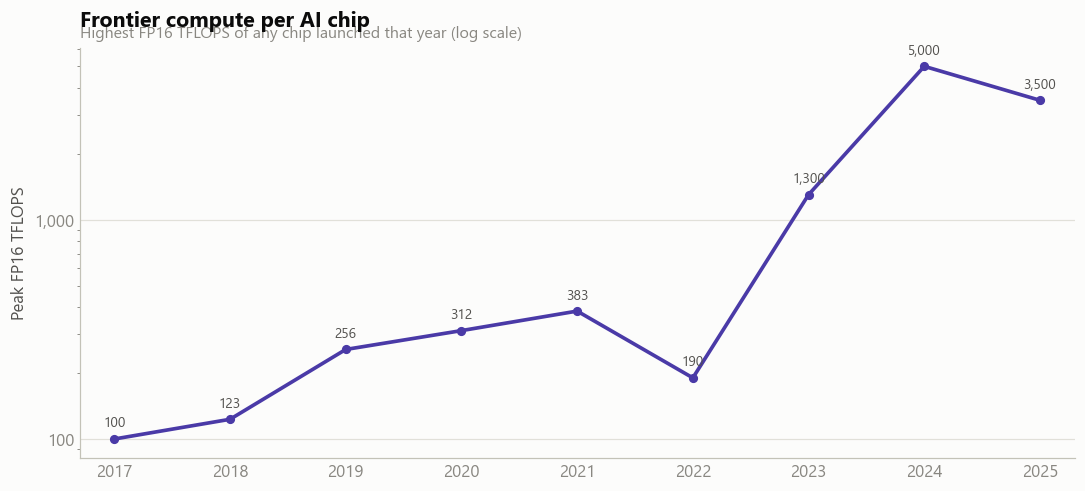

In [8]:
# Compute growth: peak FP16 TFLOPS per chip by launch year
ai["launch_year"] = pd.to_datetime(ai["launch_date"]).dt.year
frontier = ai.groupby("launch_year")["fp16_tflops"].max()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(frontier.index, frontier.values, color=VIOLET, lw=2.4, marker="o", ms=5)
for x, y in zip(frontier.index, frontier.values):
    ax.annotate(f"{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", color=INK_SOFT, fontsize=9)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlim(frontier.index.min() - 0.3, frontier.index.max() + 0.3)
style(ax, "Frontier compute per AI chip",
      "Highest FP16 TFLOPS of any chip launched that year (log scale)",
      ylab="Peak FP16 TFLOPS")
plt.tight_layout(); plt.show()

## 3 · Price dynamics: memory cycles vs AI hardware

Semiconductor products span five orders of magnitude in unit price — from a few-dollar DRAM
chip to a five-figure data-center GPU. To compare their *trends* on one axis, each series is
**indexed to 100** at its first observation; a second chart shows the raw scale on a log axis.

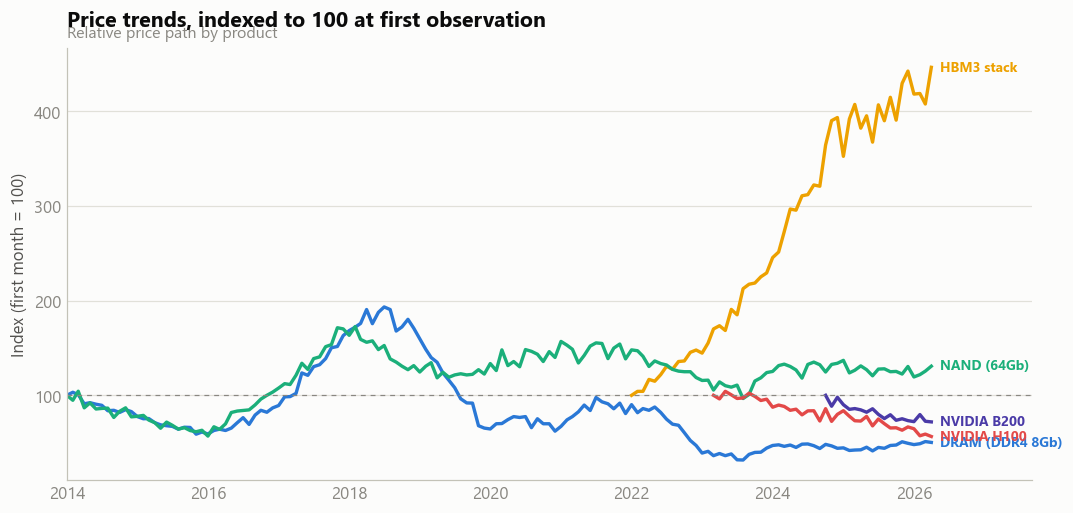

In [9]:
# Indexed price trends (common base = 100 at first observation)
prices["date"] = pd.to_datetime(prices["year_month"] + "-01")
label_map = {"DRAM_DDR4_8Gb": "DRAM (DDR4 8Gb)", "NAND_64Gb_MLC": "NAND (64Gb)",
             "HBM3_stack": "HBM3 stack", "NVIDIA_H100": "NVIDIA H100", "NVIDIA_B200": "NVIDIA B200"}
pcolor = {"DRAM (DDR4 8Gb)": BLUE, "NAND (64Gb)": AQUA, "HBM3 stack": YELLOW,
          "NVIDIA H100": RED, "NVIDIA B200": VIOLET}

fig, ax = plt.subplots(figsize=(10, 4.8))
for prod, g in prices.groupby("product"):
    g = g.sort_values("date")
    name = label_map.get(prod, prod)
    idx = g["price"].values / g["price"].values[0] * 100
    ax.plot(g["date"], idx, color=pcolor.get(name, MUTED), lw=2.2, label=name)
    ax.annotate(name, (g["date"].values[-1], idx[-1]), textcoords="offset points",
                xytext=(6, 0), va="center", color=pcolor.get(name, MUTED),
                fontsize=9, fontweight="bold")
ax.axhline(100, color=MUTED, lw=0.8, ls=(0, (4, 4)))
ax.set_xlim(prices["date"].min(), prices["date"].max() + pd.Timedelta(days=520))
style(ax, "Price trends, indexed to 100 at first observation",
      "Relative price path by product", ylab="Index (first month = 100)")
plt.tight_layout(); plt.show()

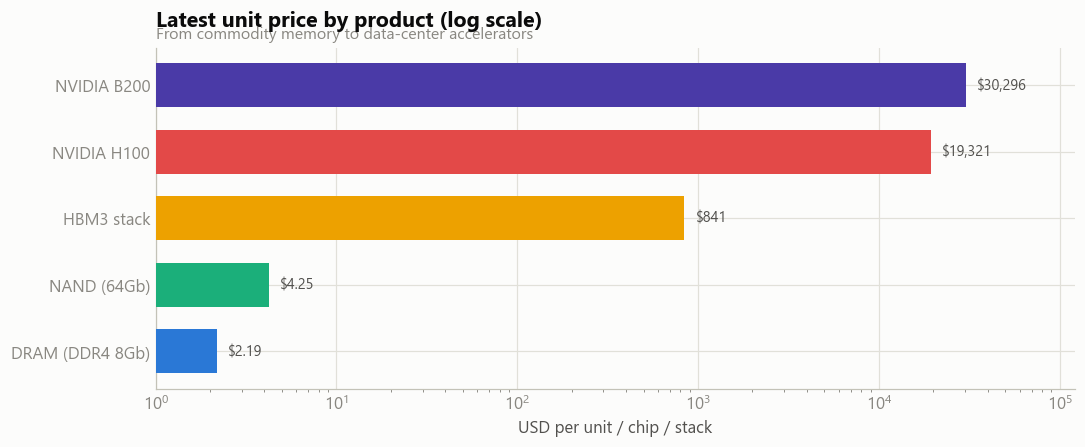

In [10]:
# Latest absolute unit price by product (log scale shows the 5-orders-of-magnitude span)
latest_px = (prices.sort_values("date").groupby("product").tail(1)
             .assign(name=lambda d: d["product"].map(label_map))
             .sort_values("price"))

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh(latest_px["name"], latest_px["price"],
               color=[pcolor.get(n, MUTED) for n in latest_px["name"]], height=0.66, zorder=3)
for b, v in zip(bars, latest_px["price"]):
    ax.text(b.get_width()*1.15, b.get_y()+b.get_height()/2,
            f"${v:,.0f}" if v >= 100 else f"${v:,.2f}",
            va="center", color=INK_SOFT, fontsize=9.5)
ax.set_xscale("log")
ax.set_xlim(1, latest_px["price"].max()*4)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.grid(axis="y", visible=False)
style(ax, "Latest unit price by product (log scale)",
      "From commodity memory to data-center accelerators", xlab="USD per unit / chip / stack")
plt.tight_layout(); plt.show()

## 4 · The race for fab capacity

Wafer fabrication is the industry's hardest bottleneck. Here we track monthly wafer capacity
by country and the split between **leading-edge** logic (≤7 nm) and everything else.

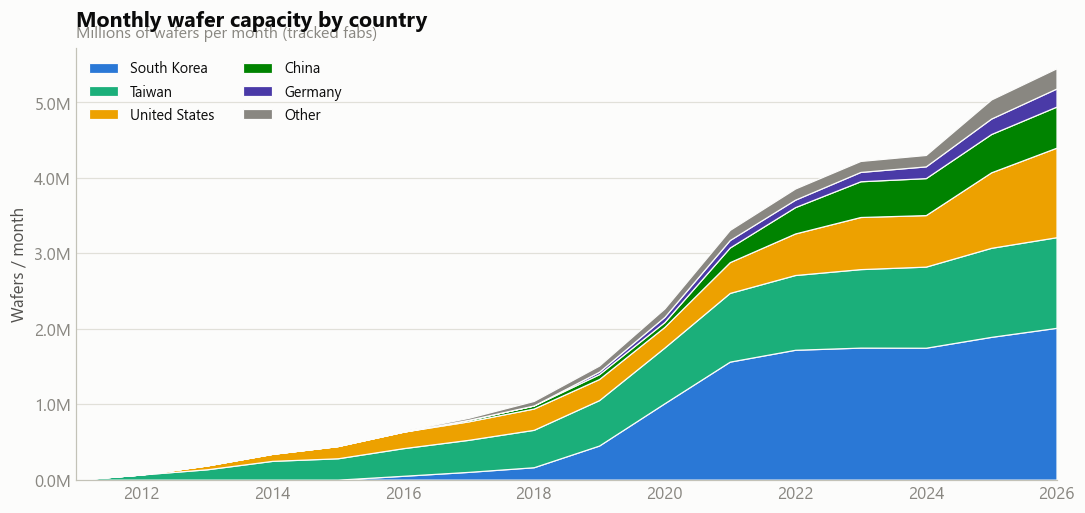

In [11]:
# Monthly wafer capacity by country over time (top countries + Other)
iso = {"TWN": "Taiwan", "KOR": "South Korea", "USA": "United States", "CHN": "China",
       "JPN": "Japan", "DEU": "Germany", "NLD": "Netherlands", "ISR": "Israel", "ITA": "Italy"}
fab["country"] = fab["country_iso3"].map(iso).fillna(fab["country_iso3"])
cap = fab.groupby(["year", "country"])["monthly_wafer_capacity"].sum().unstack("country").fillna(0)
tot_c = cap.sum().sort_values(ascending=False)
topc = list(tot_c.head(5).index)
capp = cap[topc].copy(); capp["Other"] = cap.drop(columns=topc).sum(axis=1)
cser = topc + ["Other"]
ccol = {name: CAT[i] for i, name in enumerate(topc)}; ccol["Other"] = MUTED

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.stackplot(capp.index, [capp[s].values/1e6 for s in cser],
             labels=cser, colors=[ccol[s] for s in cser],
             edgecolor=SURFACE, linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))
ax.set_xlim(capp.index.min(), capp.index.max())
style(ax, "Monthly wafer capacity by country",
      "Millions of wafers per month (tracked fabs)", ylab="Wafers / month")
ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2)
plt.tight_layout(); plt.show()

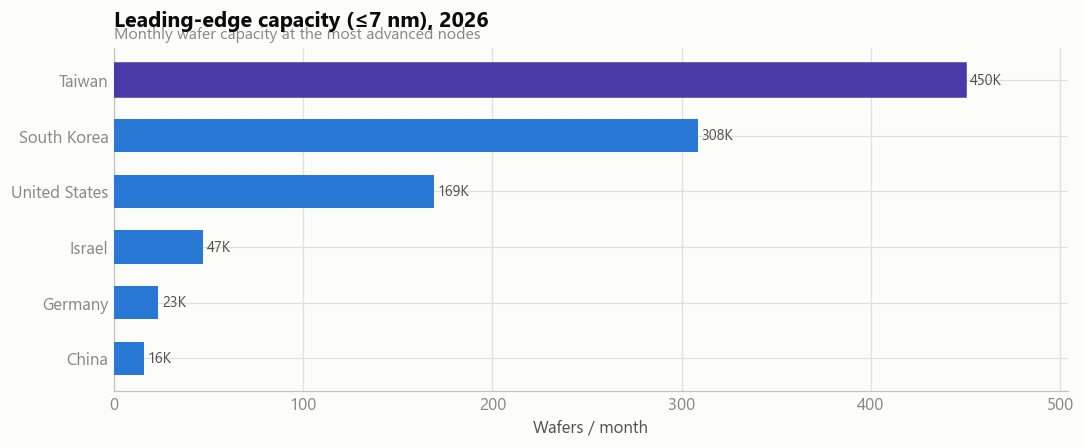

In [12]:
# Leading-edge (<=7nm) capacity by country in the latest year
leading = fab[(fab["process_node_nm"] <= 7) & (fab["year"] == fab["year"].max())]
le = leading.groupby("country")["monthly_wafer_capacity"].sum().sort_values()
le = le[le > 0]

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh(le.index, le.values/1e3, color=BLUE, height=0.6, zorder=3)
bars[-1].set_color(VIOLET)
for b, v in zip(bars, le.values):
    ax.text(b.get_width()+2, b.get_y()+b.get_height()/2, f"{v/1e3:,.0f}K",
            va="center", color=INK_SOFT, fontsize=9.5)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
style(ax, f"Leading-edge capacity (≤7 nm), {fab['year'].max()}",
      "Monthly wafer capacity at the most advanced nodes", xlab="Wafers / month")
plt.tight_layout(); plt.show()

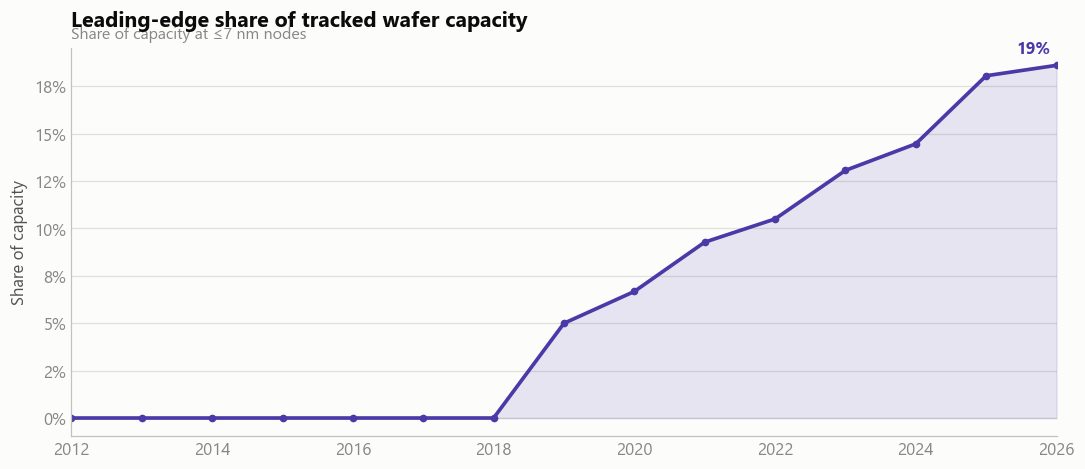

In [13]:
# Leading-edge share of total capacity over time
fab["is_leading"] = fab["process_node_nm"] <= 7
node_year = fab.groupby(["year", "is_leading"])["monthly_wafer_capacity"].sum().unstack().fillna(0)
node_year.columns = ["Mature (>7 nm)", "Leading-edge (≤7 nm)"]
node_year = node_year[node_year.sum(axis=1) > 0]
share_le = node_year["Leading-edge (≤7 nm)"] / node_year.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.fill_between(share_le.index, share_le.values, color=VIOLET, alpha=0.12)
ax.plot(share_le.index, share_le.values, color=VIOLET, lw=2.4, marker="o", ms=4)
ax.annotate(f"{share_le.values[-1]:.0f}%", (share_le.index[-1], share_le.values[-1]),
            textcoords="offset points", xytext=(-4, 8), ha="right",
            color=VIOLET, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(share_le.index.min(), share_le.index.max())
style(ax, "Leading-edge share of tracked wafer capacity",
      "Share of capacity at ≤7 nm nodes", ylab="Share of capacity")
plt.tight_layout(); plt.show()

## 5 · The geopolitical overlay: export controls

Since 2018, export controls have become a defining force in the industry. Each action carries a
**severity score** (1–10); we plot them on a timeline and tally them by the country imposing
them.

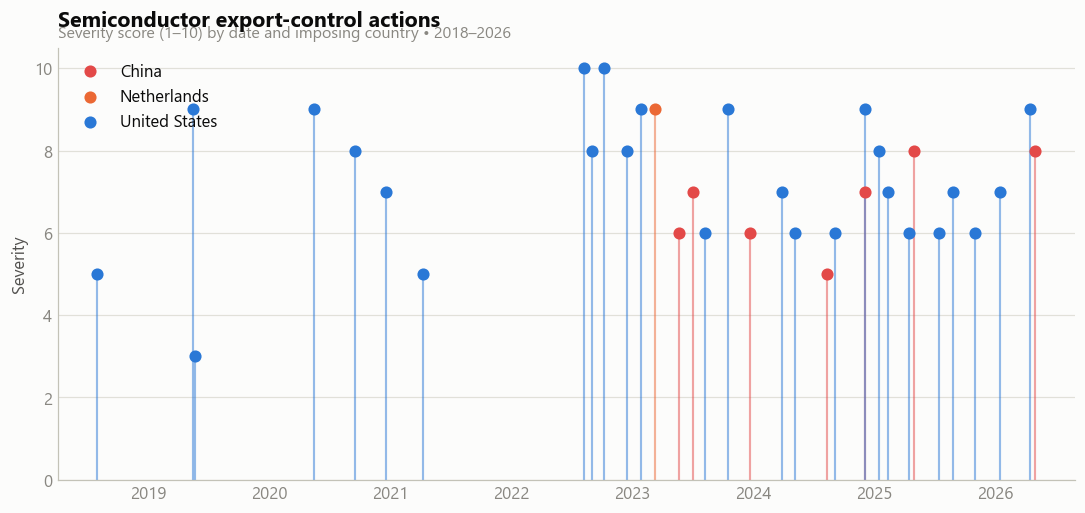

In [14]:
# Export-control timeline: severity over time, colored by imposing country
ctrl["date"] = pd.to_datetime(ctrl["date"])
imp_color = {"USA": BLUE, "NLD": ORANGE, "CHN": RED}
imp_name = {"USA": "United States", "NLD": "Netherlands", "CHN": "China"}

fig, ax = plt.subplots(figsize=(10, 4.8))
for country, g in ctrl.groupby("imposing_country"):
    ax.vlines(g["date"], 0, g["severity_score"], color=imp_color.get(country, MUTED),
              lw=1.4, alpha=0.5, zorder=2)
    ax.scatter(g["date"], g["severity_score"], color=imp_color.get(country, MUTED),
               s=48, zorder=3, label=imp_name.get(country, country))
ax.set_ylim(0, 10.5)
ax.set_xlim(ctrl["date"].min() - pd.Timedelta(days=120), ctrl["date"].max() + pd.Timedelta(days=120))
style(ax, "Semiconductor export-control actions",
      "Severity score (1–10) by date and imposing country • 2018–2026", ylab="Severity")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

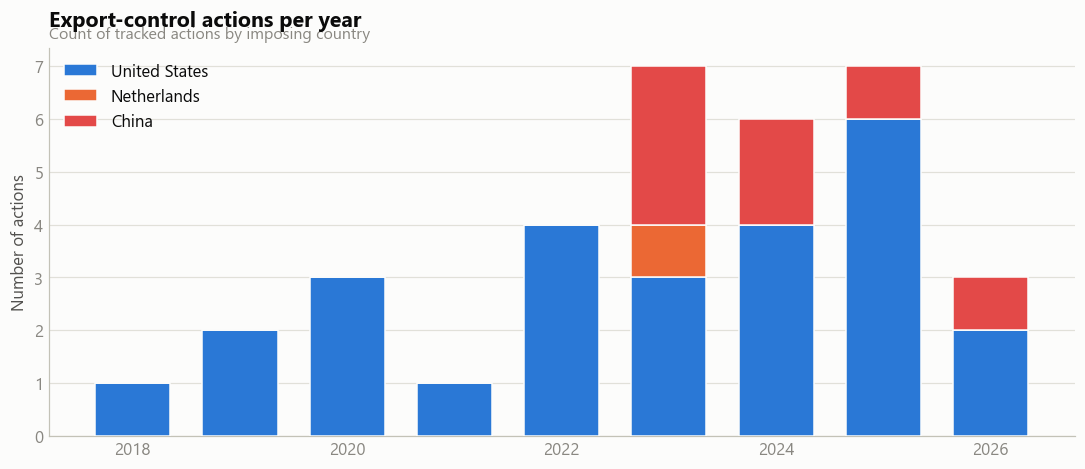

Most-targeted entities:
target
Huawei       4
ZTE          1
SMIC         1
Phytium      1
CHIPS_Act    1


In [15]:
# Count of actions per year, split by imposing country (stacked bars)
cnt = ctrl.groupby(["year", "imposing_country"]).size().unstack("imposing_country").fillna(0)
cnt = cnt.reindex(columns=[c for c in ["USA", "NLD", "CHN"] if c in cnt.columns])

fig, ax = plt.subplots(figsize=(10, 4.4))
bottom = np.zeros(len(cnt))
for country in cnt.columns:
    ax.bar(cnt.index, cnt[country], bottom=bottom, color=imp_color.get(country, MUTED),
           label=imp_name.get(country, country), width=0.7, zorder=3, edgecolor=SURFACE)
    bottom += cnt[country].values
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
style(ax, "Export-control actions per year",
      "Count of tracked actions by imposing country", ylab="Number of actions")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

print("Most-targeted entities:")
print(ctrl["target"].value_counts().head(5).to_string())

## Key takeaways

- **A trillion-dollar-scale value chain.** Tracked revenue compounds steadily across 2010–2026,
  with foundries and fabless designers capturing a growing share.
- **AI accelerators are the growth engine.** AI-chip revenue explodes after 2020 and stays highly
  concentrated in a single dominant vendor, even as challengers appear.
- **Compute per chip grows exponentially** — frontier FP16 throughput rises orders of magnitude in
  just a few years.
- **Two price worlds.** Commodity memory (DRAM/NAND) moves in sharp cycles, while data-center GPUs
  sit five orders of magnitude higher in unit price.
- **Capacity is concentrated and moving up the node curve.** A handful of countries dominate wafer
  output, and the leading-edge (≤7 nm) share keeps climbing.
- **Geopolitics is now a first-class variable.** Export-control actions escalate in frequency and
  severity from 2018 onward, reshaping supply chains.

---
*Data: "Global Semiconductor Industry 2010–2026" (Kaggle). This notebook is exploratory; figures
labelled "estimated" are dataset estimates, not official financials.*
